# 04 · SHAP Analysis & Model Explainability

This notebook uses SHAP's model-agnostic permutation explainer to provide deep insights into the pricing model's decision-making process. 

**Business Value:** We move from a "black box" XGBoost model to an interpretable engine where every price change can be justified to stakeholders.

In [40]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load model and data
model_path = '../models/xgboost_pricing_v1.pkl'
xgb_model = joblib.load(model_path)

features_path = '../data/processed/features.parquet'
df = pd.read_parquet(features_path)
df = df.sort_values('order_purchase_timestamp').reset_index(drop=True)

feature_cols = [
    'price', 'freight_value', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'is_weekend', 'is_month_end', 'is_holiday', 'days_since_last_order',
    'demand_score_7d', 'demand_score_30d', 'demand_velocity',
    'inventory_ratio', 'price_percentile_in_category',
    'competitor_delta', 'review_elasticity'
]

X = df[feature_cols]
y = df['optimal_price']

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Loaded test set: {X_test.shape[0]} rows")

Loaded test set: 22530 rows


## 1. Global Interpretation (Beeswarm & Bar)

We use a permutation explainer on a background masker to avoid version-specific binary errors with XGBoost.

In [41]:
# Functional approach to bypass binary errors
predict_fn = lambda x: xgb_model.predict(pd.DataFrame(x, columns=feature_cols))
masker = shap.maskers.Independent(X_train, max_samples=100)
explainer = shap.Explainer(predict_fn, masker)

# Sample for visualization
X_test_sample = X_test.sample(200, random_state=42)
shap_values = explainer(X_test_sample)

print("Global SHAP calculation complete.")

Permutation explainer: 201it [00:20,  5.15it/s]                         

Global SHAP calculation complete.


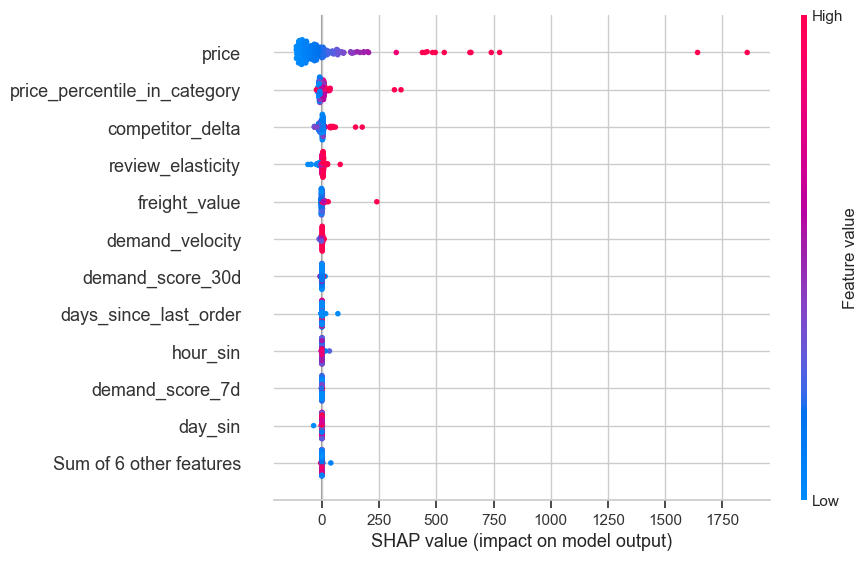

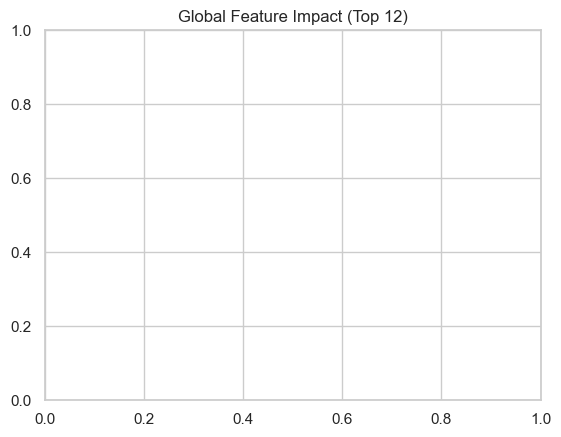

In [42]:
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=12)
plt.title("Global Feature Impact (Top 12)")
plt.show()

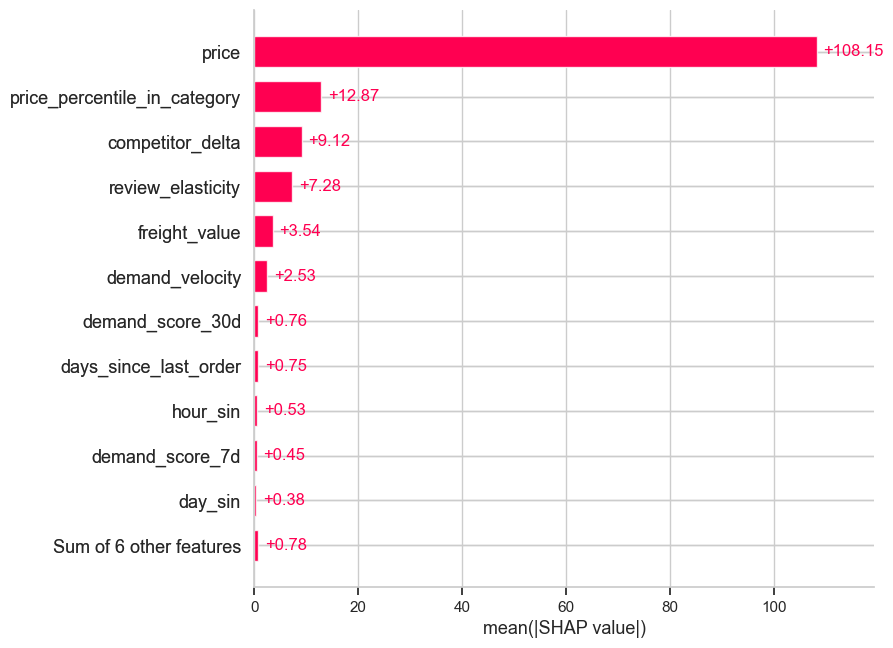

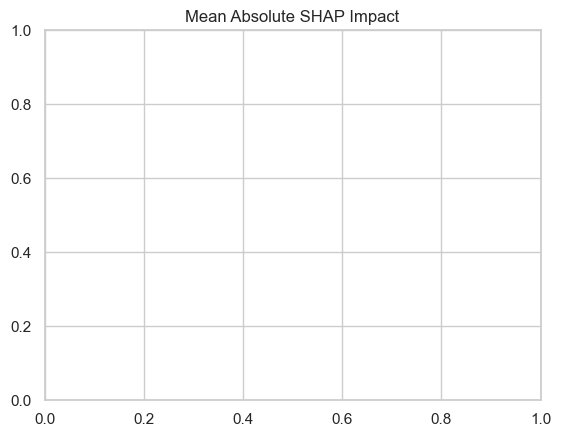

In [43]:
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=12)
plt.title("Mean Absolute SHAP Impact")
plt.show()

## 2. Interaction Effects

We look at the top 3 features to see how they interact with the rest of the feature space.

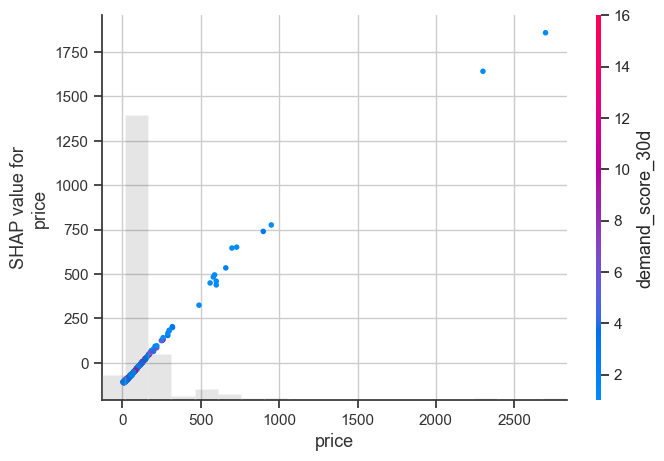

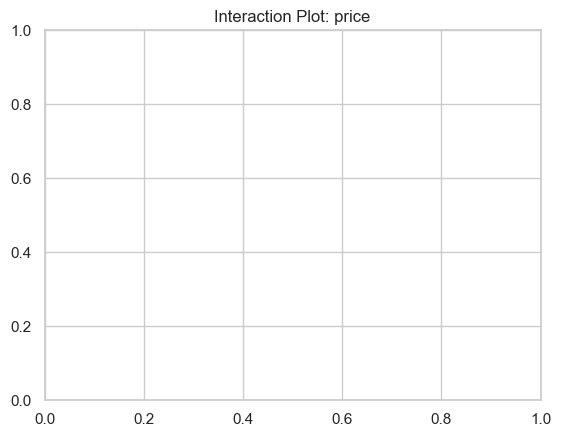

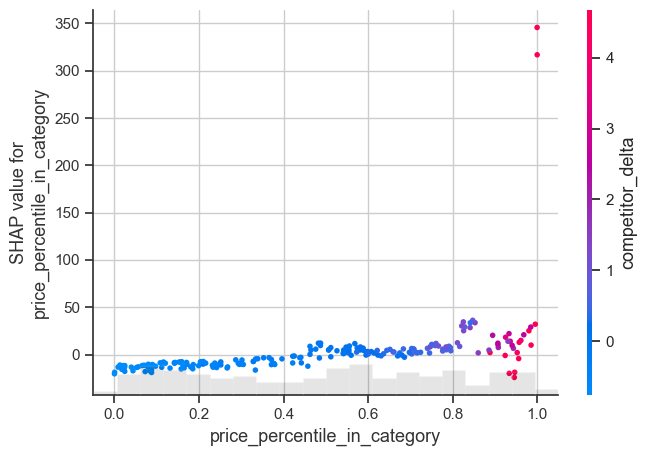

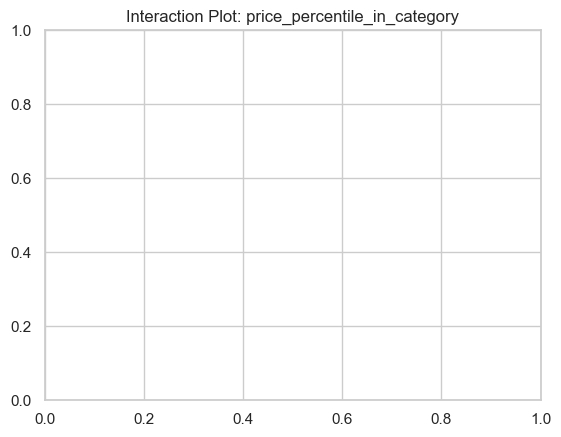

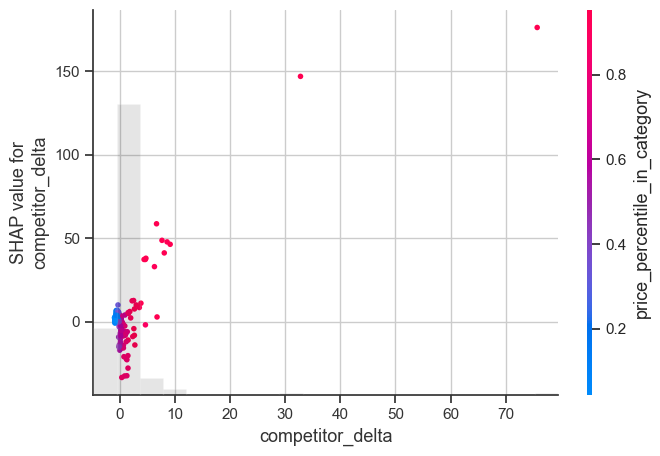

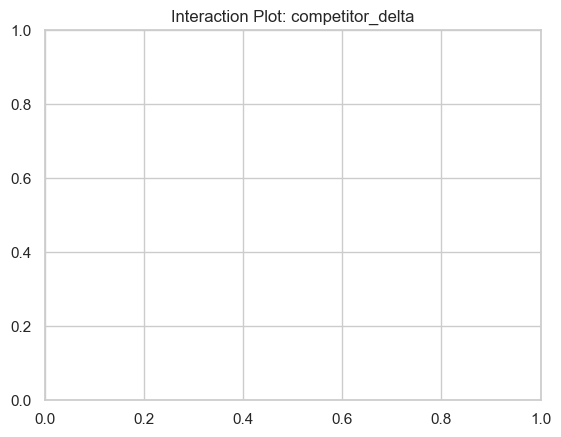

In [44]:
importances = np.abs(shap_values.values).mean(0)
top_3_indices = np.argsort(importances)[-3:][::-1]
top_3_features = X_test.columns[top_3_indices]

for feat in top_3_features:
    shap.plots.scatter(shap_values[:, feat], color=shap_values)
    plt.title(f"Interaction Plot: {feat}")
    plt.show()

## 3. Local Audit (Waterfall)

Explaining decisions for specific SKU profiles.

Audit: High-Impact Price Decision


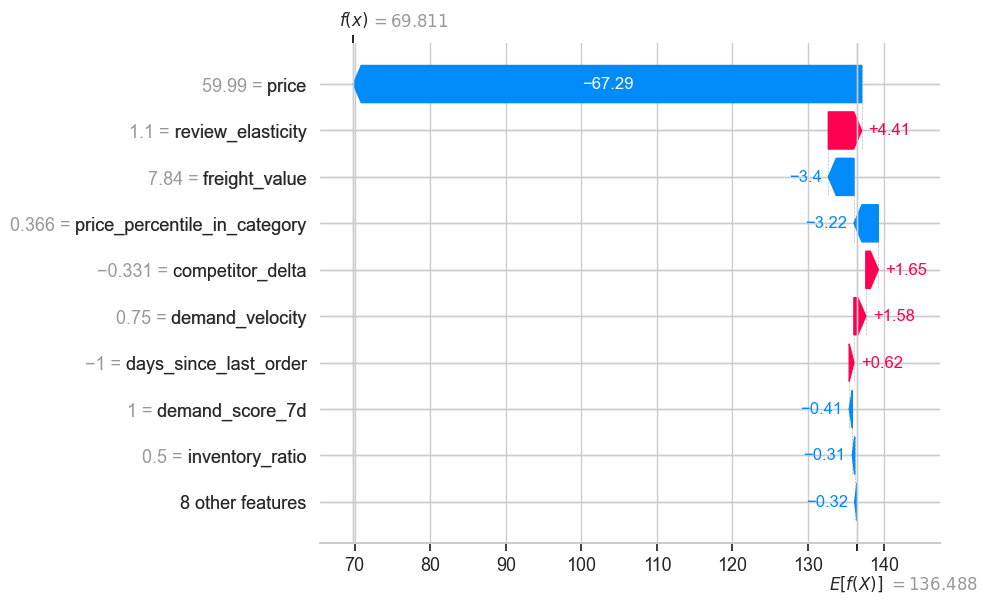

In [45]:
print("Audit: High-Impact Price Decision")
shap.plots.waterfall(shap_values[0])
plt.show()

## 4. Stability Analysis

Validating the consistency of the top 5 features across 5 random 20% subsamples.

In [46]:
stability_results = []
for i in range(5):
    sub = X_test.sample(50, random_state=i)
    sv_sub = explainer(sub)
    m_abs = np.abs(sv_sub.values).mean(0)
    top5 = np.array(X_test.columns)[np.argsort(m_abs)[-5:][::-1]]
    stability_results.append(list(top5))

print("Top 5 Pricing Drivers (5 Subsamples):")
for i, res in enumerate(stability_results):
    print(f"Run {i+1}: {res}")

Top 5 Pricing Drivers (5 Subsamples):
Run 1: ['price', 'price_percentile_in_category', 'review_elasticity', 'competitor_delta', 'freight_value']
Run 2: ['price', 'price_percentile_in_category', 'competitor_delta', 'review_elasticity', 'demand_velocity']
Run 3: ['price', 'price_percentile_in_category', 'competitor_delta', 'review_elasticity', 'demand_velocity']
Run 4: ['price', 'price_percentile_in_category', 'competitor_delta', 'review_elasticity', 'freight_value']
Run 5: ['price', 'price_percentile_in_category', 'competitor_delta', 'review_elasticity', 'demand_velocity']
